Descripció
Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

___

# Nivell 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.


## 1.1. Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

In [1]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from datetime import date as fechas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import pandas as pd

In [2]:
load_dotenv()

try:
    engine = create_engine(
        f"mysql+mysqlconnector://{os.getenv('user')}:{os.getenv('password')}"
        f"@{os.getenv('host')}/{os.getenv('database')}"
    )

    df_transaction = pd.read_sql("SELECT * FROM transaction", engine)
    df_company = pd.read_sql("SELECT * FROM company", engine)
    df_credit_card = pd.read_sql("SELECT * FROM credit_card", engine)
    df_credit_card_status = pd.read_sql("SELECT * FROM credit_card_status", engine)
    df_product = pd.read_sql("SELECT * FROM product", engine)
    df_transaction_product = pd.read_sql("SELECT * FROM transaction_product", engine)
    df_user = pd.read_sql("SELECT * FROM user", engine)

    print("Datos cargados correctamente.")

except Exception as e:
    print("Error while connecting to MySQL:", e)
finally:
    engine.dispose()
    print(f"MySQL connection closed.")

Datos cargados correctamente.
MySQL connection closed.


## 1.2. Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

### Una variable numérica: Distribución de precio de producto

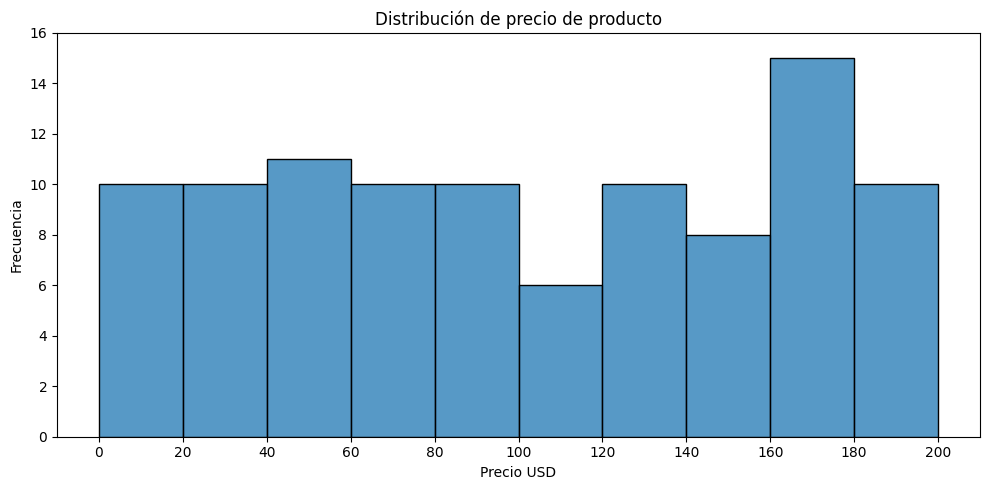

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(
    df_product['price'], 
    binrange=(0, 200),
    binwidth=20,
    kde=False
)
plt.title('Distribución de precio de producto')
plt.xlabel('Precio USD')
plt.ylabel('Frecuencia')
plt.xticks(np.arange(0, 210, 20))
plt.yticks(np.arange(0, 18, 2))
plt.tight_layout()
plt.show()

📊 A lo largo de 10 rangos, los precios de los productos se destribuyen de manera relativamente uniforme. El grueso de los productos se encuentran entre los 0 USD y los 100 USD. El rango con mayor concentración es el de entre 160 USD y 180 USD (15 productos) y la menor en el de entre 100 USD y 120 USD (6 productos), lo que nos dice que la empresa cuenta con un catálogo con  una gran variedad de precios.

### Dos variables numéricas: Relación entre precio y peso de producto

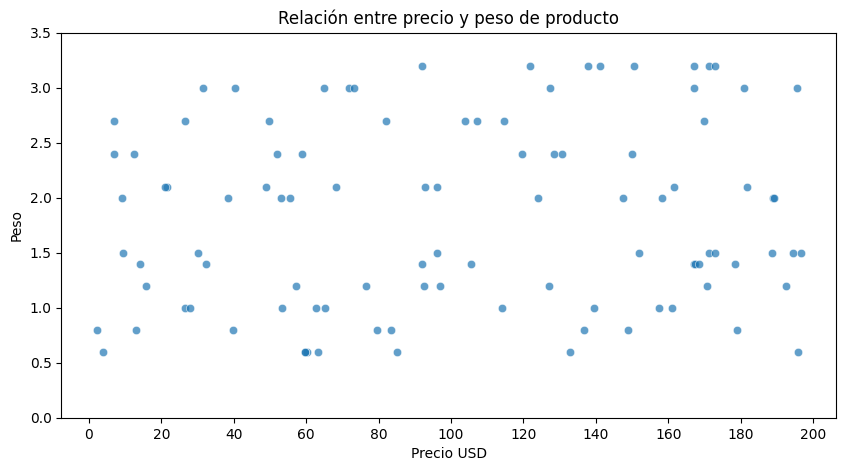

In [4]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_product,
    x='price',
    y='weight',
    alpha=0.7
)
plt.title('Relación entre precio y peso de producto')
plt.xlabel('Precio USD')
plt.ylabel('Peso')
plt.xticks(np.arange(0, 210, 20))
plt.yticks(np.arange(0, 4, 0.5))
plt.show()

* Las unidades de Peso no están reflejadas en el origen del dataset

🔍 No existe correlación entre las variables de precio de producto y peso de producto, todos los valores de peso aparecen a lo largo de todos los valores de precio.

### Una variable categórica: Número de usuarios por región

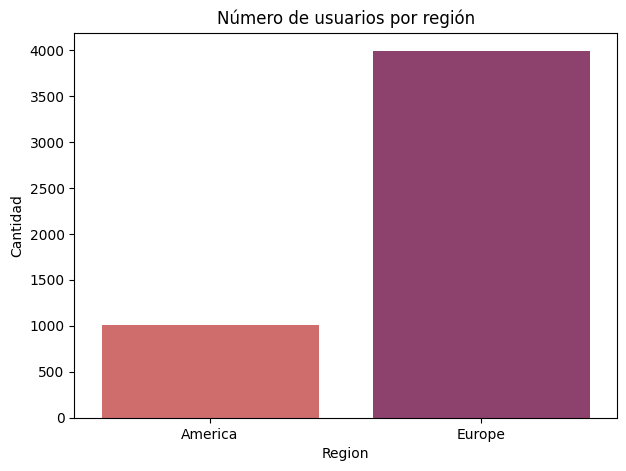

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_user,
    x='region',
    palette='flare',
    hue='region',
)
plt.title('Número de usuarios por región')
plt.xlabel('Region')
plt.ylabel('Cantidad')
plt.show()

👩‍🦳👨‍🦱👩‍🦰 El 80% de los usuarios pertenecen a Europa, mientras que el 20% es de la región América, lo que indica una base de clientes fuertemente concentrada en el mercado europeo.

### Una variable categórica y una numérica: Monto de transacción por region

In [6]:
df_transaction_user = (df_transaction
                       .merge(df_user,
                              left_on='user_id', 
                              right_on='id')
                       .reset_index(drop=True)
)
df_transaction_user['year'] = df_transaction_user['timestamp'].dt.year

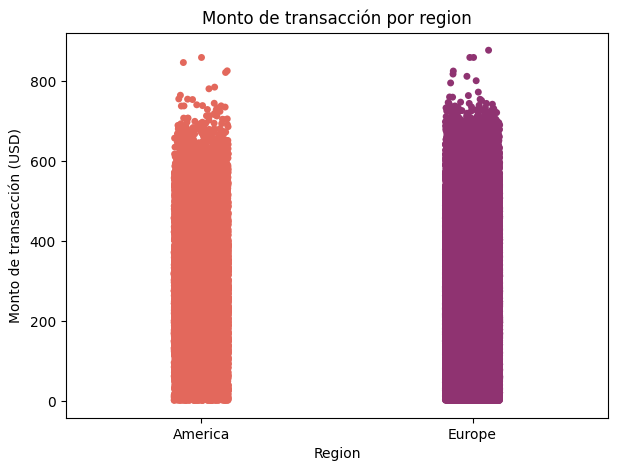

In [7]:
plt.figure(figsize=(7, 5))
sns.stripplot(
    data=df_transaction_user,
    x='region',
    y='amount',
    palette=({"America":'#e3685c',"Europe":'#8f3371'}),
    hue='region',
    legend=False,
    order=['America', 'Europe']
)
plt.title('Monto de transacción por region')
plt.xlabel('Region')
plt.ylabel('Monto de transacción (USD)')
plt.show()

🗺 A pesar de la diferencia en número de usuarios, el monto de transacción se distribuye de forma similar en ambas regiones, entre ~0 USD y ~700 USD.

### Dos variables categóricas: Usuarios por país y región

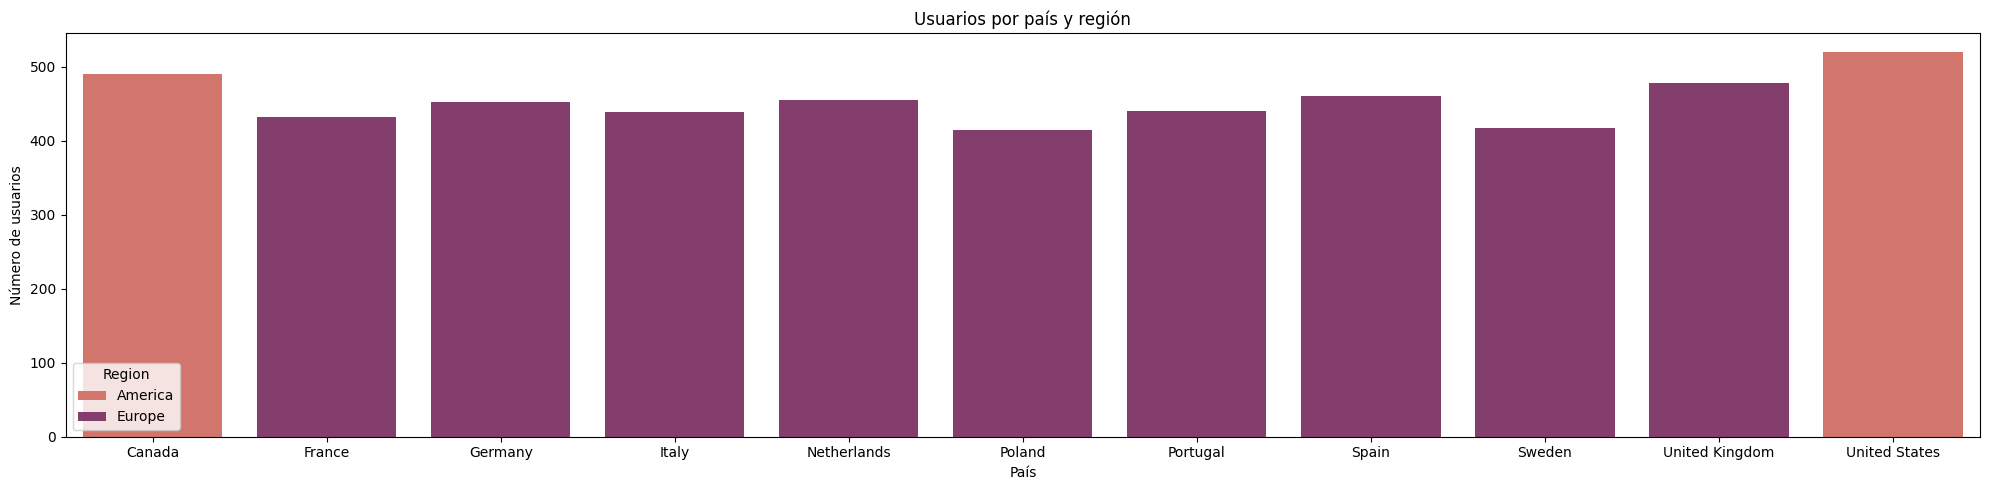

In [8]:
df_pais = (df_user
    .groupby(['country', 'region'])['id']
    .nunique()
    .reset_index(name='count')
)

plt.figure(figsize=(20, 5))
sns.barplot(
    data=df_pais,
    x='country',
    y='count',
    hue='region',
    palette={"America": '#e3685c', "Europe": '#8f3371'},
    dodge=False
)
plt.title('Usuarios por país y región')
plt.xlabel('País')
plt.ylabel('Número de usuarios')
plt.legend(loc='lower left', title='Region')
plt.tight_layout()
plt.show()

💃🌏🤠 Europa concentra más usuarios en total al contar con presencia en 9 países frente a los 2 de la región América; sin embargo, a nivel individual, Estados Unidos es el país con mayor número de usuarios con algo más de 500.

### Tres variables combinadas: Evolución del monto medio anual de transacción por región

In [9]:
df_anual = (df_transaction_user
            .groupby(['year', 'region'])['amount']
            .mean()
            .reset_index()
)

fig = px.line(
    df_anual,
    x='year',
    y='amount',
    color='region',
    color_discrete_sequence=['#e3685c', '#8f3371'],
    title='Evolución del monto medio anual de transacción por región',
    labels={
        'year': 'Año',
        'amount': 'Monto medio anual (USD)',
        'region': 'Region'
    },
    markers=True
)

fig.update_layout(
    xaxis=dict(tickmode='linear', dtick=1),  
    yaxis=dict(range=[0, 300]),
    legend=dict(x=0, y=0),
)
fig.show()

📈 Ambas regiones mantienen el monto medio de transacción en un rango estrecho y estable a lo largo del período. América muestra mayor volatilidad: alcanza su pico en 2019 (~267 USD) y su caída más pronunciada en 2022 (~253 USD). Europa es algo más estable, entre ~256 USD y ~263 USD.

### Crea un Pairplot: Precio, peso y número de transacciones por producto

In [10]:
df_veces_comprado = (df_transaction_product
                     .groupby('product_id')['transaction_id']
                     .count()
                     .reset_index()
                     .rename(columns={'transaction_id': 'veces_comprado'})
)

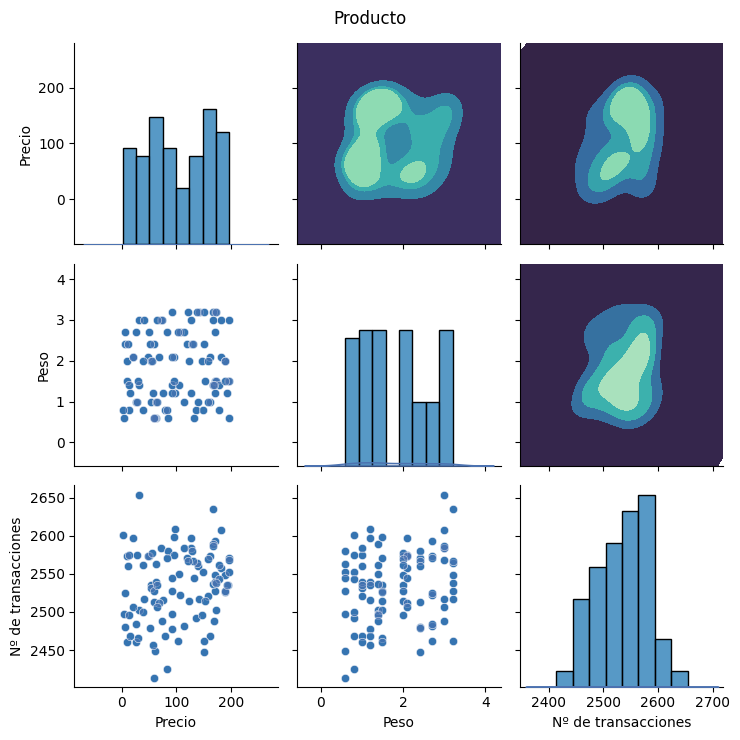

In [11]:
df_pair = (df_product
           .merge(df_veces_comprado, 
                  left_on='id',
                  right_on='product_id')
                  .reset_index(drop=True)
)

df_pair = df_pair.rename(columns={'price':'Precio',
                                  'weight': 'Peso',
                                  'veces_comprado': 'Nº de transacciones'})

g = sns.pairplot(df_pair[['Precio','Peso','Nº de transacciones']])
g.map_lower(sns.scatterplot, alpha=0.5, color='#4C72B0')
g.map_upper(sns.kdeplot, levels=5, fill=True, thresh=0, cmap='mako')
g.map_diag(sns.kdeplot, fill=True, color='#4C72B0')
plt.suptitle('Producto')
plt.tight_layout()
plt.show()

🔵📊🌌 Ningún par de variables presenta correlación, los puntos se distribuyen de forma aleatoria sin tendencia aparente. Destaca una concentración de los productos comprados entre 2500 y 2600 veces, que es más evidente en su relación con el peso que con el precio.

___

# Nivell 2

## 2.1. Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

### Correlación: Precio y número de transacciones por producto

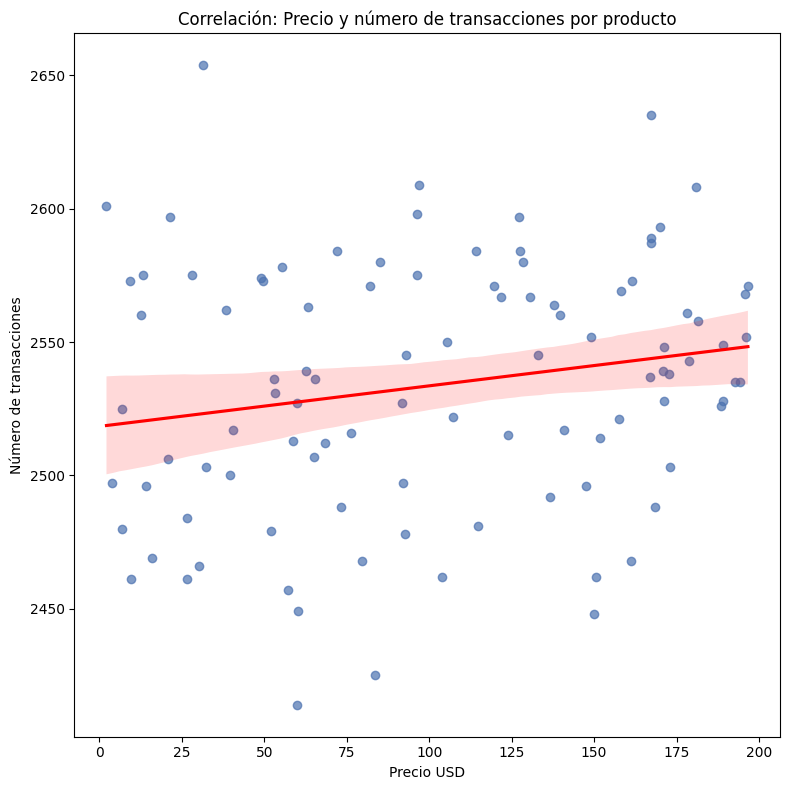

In [12]:
df_producto_veces_comprado = (df_veces_comprado
                              .merge(df_product[['id','price']],
                                     left_on='product_id',
                                     right_on='id')
                              .reset_index(drop=True)
)

plt.figure(figsize=(8, 8))
sns.regplot(data=df_producto_veces_comprado,
             x='price',
             y='veces_comprado',
             scatter_kws={'alpha': 0.7, 'color': '#4C72B0'},
             line_kws={'color': 'red'})
plt.title("Correlación: Precio y número de transacciones por producto")
plt.xlabel("Precio USD")
plt.ylabel("Número de transacciones")
plt.tight_layout()
plt.show()

In [13]:
from scipy import stats
from scipy.stats import pearsonr


r, p = pearsonr(df_producto_veces_comprado['price'], df_producto_veces_comprado['veces_comprado'])
print(f"Pearson r: {r:.3f}")
print(f"p-value: {p:.3f}")

slope, intercept, r, p, se = stats.linregress(
    df_producto_veces_comprado['price'], 
    df_producto_veces_comprado['veces_comprado']
)

t_crit = stats.t.ppf(0.975, df=len(df_producto_veces_comprado)-2)
ci_low = slope - t_crit * se
ci_high = slope + t_crit * se

print(f"Pendiente: {slope:.4f}")
print(f"IC 95%: ({ci_low:.4f}, {ci_high:.4f})")

Pearson r: 0.192
p-value: 0.055
Pendiente: 0.1521
IC 95%: (-0.0035, 0.3076)


🛒 El precio del producto no presenta correlación estadísticamente significativa con el número de veces que es comprado (r = 0.192, p = 0.055). La pendiente estimada es de 0.15 transacciones por dólar, pero el intervalo de confianza al 95% incluye el cero (-0.004, 0.308), lo que indica que no se puede descartar que la relación real sea nula. Con un catálogo mayor, esta relación podría confirmarse o descartarse.

## 2.2. Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

### Correlación: Edad y monto de transacción

In [14]:
df_user['birth_date'] = pd.to_datetime(df_user['birth_date'])

def calcul_edat(data_naixament: pd.Series) -> int:
    """
    Calcula la edad actual según una fecha de nacimiento dada.

    Args:
        data_naixament: datetime, fecha de nacimiento.
    
    Returns:
        edat: int, resultado de restar la data_naixement menos la fecha actual (avui). 
    """
    avui = fechas.today()
    edat = avui.year - data_naixament.year

    if(avui.month, avui.day) < (data_naixament.month, data_naixament.day):
        edat -= 1
    return edat

df_user['age'] = df_user['birth_date'].apply(calcul_edat)

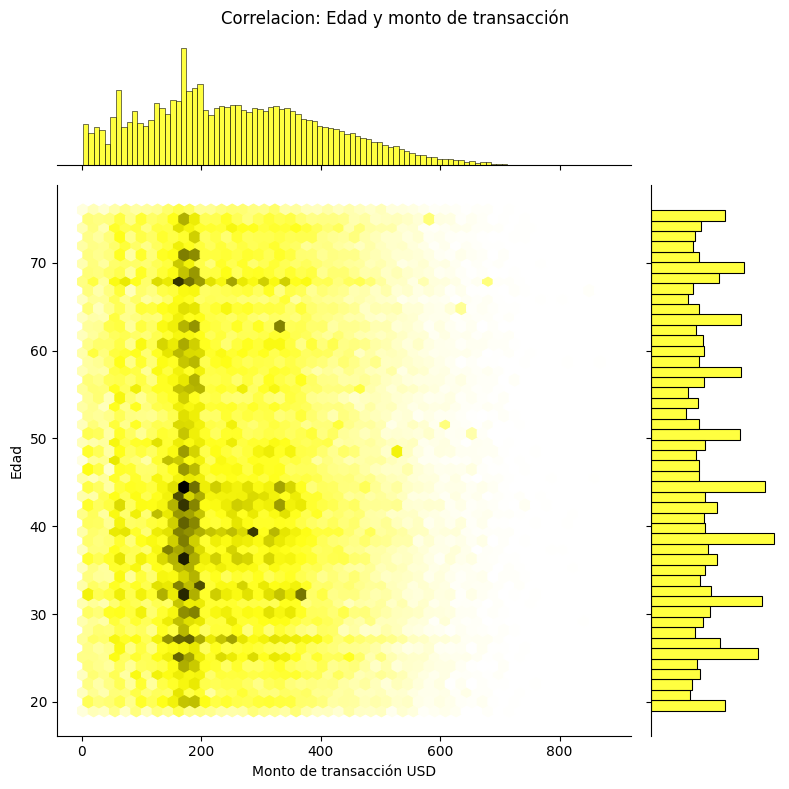

In [15]:
df_merged_age = df_transaction.merge(
                df_user[['id', 'age']], 
                left_on='user_id', 
                right_on='id'
)

sns.jointplot(data= df_merged_age,
              x='amount',
              y='age', 
              kind='hex', 
              color='yellow',
              height=8,
              ratio=4)
plt.suptitle("Correlacion: Edad y monto de transacción")
plt.xlabel("Monto de transacción USD")
plt.ylabel("Edad")
plt.tight_layout()
plt.show()

In [16]:
from scipy import stats
from scipy.stats import pearsonr

r, p = pearsonr(df_merged_age['amount'], df_merged_age['age'])
print(f"Pearson r: {r:.3f}")
print(f"p-value: {p:.3f}")

slope, intercept, r, p, se = stats.linregress(
    df_merged_age['amount'], 
    df_merged_age['age']
)

t_crit = stats.t.ppf(0.975, df=len(df_merged_age)-2)
ci_low = slope - t_crit * se
ci_high = slope + t_crit * se

print(f"Pendiente: {slope:.4f}")
print(f"IC 95%: ({ci_low:.4f}, {ci_high:.4f})")

Pearson r: -0.002
p-value: 0.600
Pendiente: -0.0002
IC 95%: (-0.0009, 0.0005)


💲👨‍🦳👨‍🦰 La edad no influye en el monto gastado por transacción (r = -0.002, p = 0.600). La concentración de transacciones alrededor de los 200 USD visible refleja únicamente la distribucion individual de cada variable pero no una relación.

___

# Nivell 3

## 3.1. Transfereix totes les visualitzacions del Nivell 1 a Power BI utilitzant scripts de Python.

### *Ver el archivo .pibx adjunto en el repositorio